Training data shape: (643928, 32)
Testing data shape: (160982, 32)

Training XGBoost model... (This will be fast thanks to 'hist' method)

--- XGBoost Performance ---
Training R^2: 0.7575
Testing R^2:  0.7364
Testing RMSE: 88.99
Testing MAE:  64.58


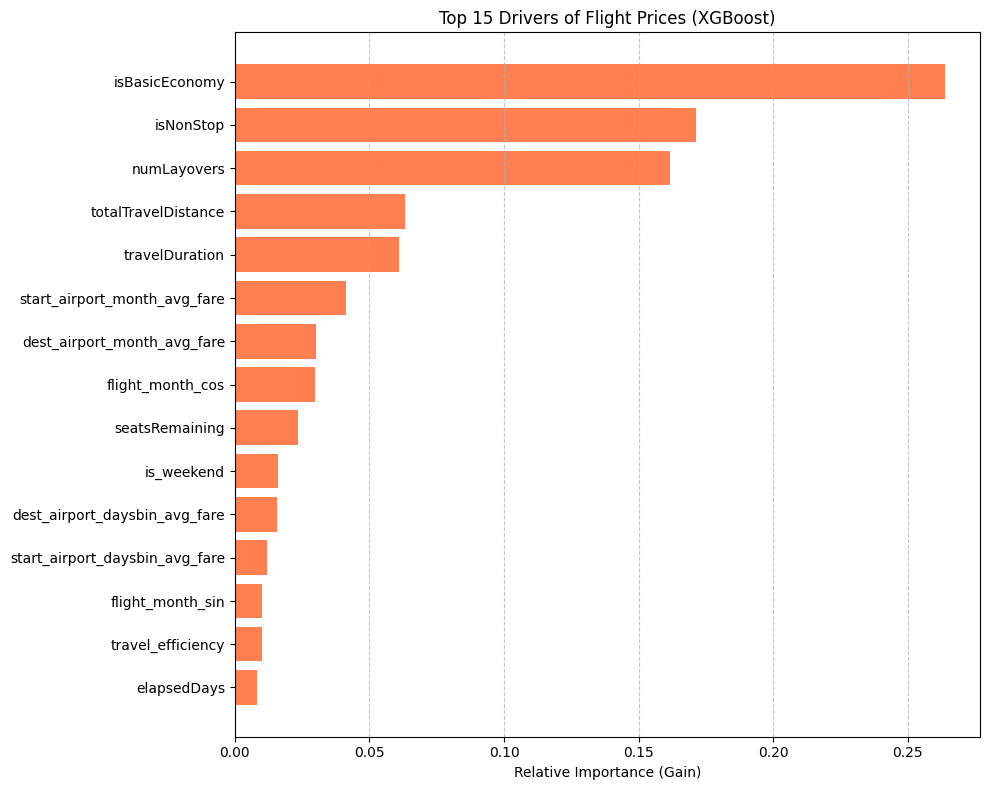

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
df = pd.read_parquet("final_32_columns_no_outliers.parquet")

# Remove outliers with totalFare above $1000


# Target
y = df["totalFare"].copy()

# Features (32-column set without target)
X_32 = df.drop(columns=["totalFare"]).copy()
# 1. Define Features and Target (Using X_32 from your previous step)
# Assuming X_32 and y are already in your environment
X = X_32.copy()
y_target = y.copy()

# 2. Train-Test Split (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y_target, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")
# ==========================================

# 3. Initialize the XGBoost Regressor
# - tree_method='hist': Optimizes memory and speed for datasets >500k rows
# - n_estimators: Number of trees to build
# - learning_rate: How much each tree contributes to the final answer
# - max_depth: How deep each tree can grow
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist', 
    random_state=42,
    n_jobs=-1
)

# 4. Train the Model
print("\nTraining XGBoost model... (This will be fast thanks to 'hist' method)")
xgb_model.fit(X_train, y_train)

# 5. Make Predictions
y_pred_train = xgb_model.predict(X_train)
y_pred_test = xgb_model.predict(X_test)

# 6. Evaluate Performance
print("\n--- XGBoost Performance ---")
print(f"Training R^2: {r2_score(y_train, y_pred_train):.4f}")
print(f"Testing R^2:  {r2_score(y_test, y_pred_test):.4f}")
print(f"Testing RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.2f}")
print(f"Testing MAE:  {mean_absolute_error(y_test, y_pred_test):.2f}")

# 7. Feature Importance Visualization
# XGBoost calculates importance based on 'Gain' (how much a feature improves accuracy)
importances = xgb_model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

# Plot the Top 15 most important features
plt.figure(figsize=(10, 8))
top_15 = importance_df.tail(15)
plt.barh(top_15['Feature'], top_15['Importance'], color='coral')
plt.xlabel('Relative Importance (Gain)')
plt.title('Top 15 Drivers of Flight Prices (XGBoost)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# doing using log

Training data shape: (643928, 32)
Testing data shape: (160982, 32)

Training XGBoost model... (This will be fast thanks to 'hist' method)

--- XGBoost Performance ---
Training R^2: 0.7575
Testing R^2:  0.7364
Testing RMSE: 88.99
Testing MAE:  64.58


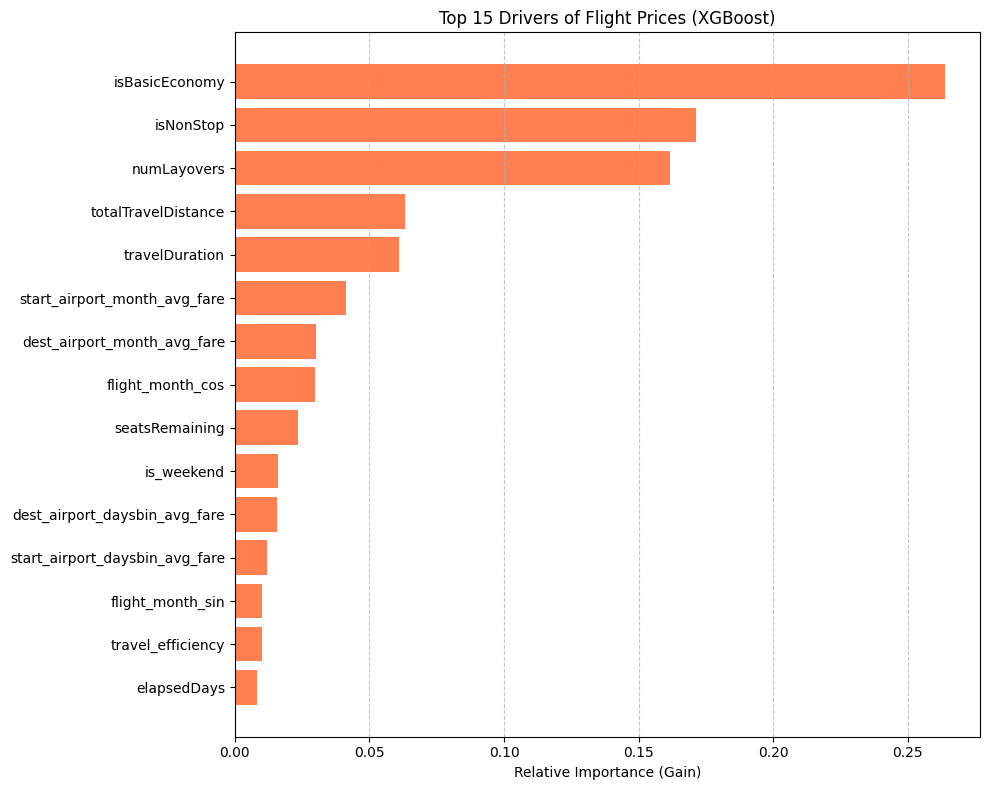

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
df = pd.read_parquet("final_32_columns_no_outliers.parquet")



# Target
y = df["totalFare"].copy()

# Features (32-column set without target)
X_32 = df.drop(columns=["totalFare"]).copy()
# 1. Define Features and Target (Using X_32 from your previous step)
# Assuming X_32 and y are already in your environment
X = X_32.copy()
y_target = y.copy()

# 2. Train-Test Split (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y_target, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")
# ==========================================
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)


# 3. Initialize the XGBoost Regressor
# - tree_method='hist': Optimizes memory and speed for datasets >500k rows
# - n_estimators: Number of trees to build
# - learning_rate: How much each tree contributes to the final answer
# - max_depth: How deep each tree can grow
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist', 
    random_state=42,
    n_jobs=-1
)

# 4. Train the Model
print("\nTraining XGBoost model... (This will be fast thanks to 'hist' method)")
xgb_model.fit(X_train, y_train)

# 5. Make Predictions
y_pred_train = xgb_model.predict(X_train)
y_pred_test = xgb_model.predict(X_test)

# 6. Evaluate Performance
print("\n--- XGBoost Performance ---")
print(f"Training R^2: {r2_score(y_train, y_pred_train):.4f}")
print(f"Testing R^2:  {r2_score(y_test, y_pred_test):.4f}")
print(f"Testing RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.2f}")
print(f"Testing MAE:  {mean_absolute_error(y_test, y_pred_test):.2f}")

# 7. Feature Importance Visualization
# XGBoost calculates importance based on 'Gain' (how much a feature improves accuracy)
importances = xgb_model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

# Plot the Top 15 most important features
plt.figure(figsize=(10, 8))
top_15 = importance_df.tail(15)
plt.barh(top_15['Feature'], top_15['Importance'], color='coral')
plt.xlabel('Relative Importance (Gain)')
plt.title('Top 15 Drivers of Flight Prices (XGBoost)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# randomised CV

In [3]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
import gc # Garbage collector to free up RAM

# 1. Train-Test Split (100% of data)


# Apply Log Trick
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# ==========================================
# MEMORY-SAFE HYPERPARAMETER TUNING
# ==========================================
print("Creating a 20% sample for safe tuning...")
# Take a random 20% of the training data just to find the best settings
X_tune = X_train.sample(frac=0.2, random_state=42)
y_tune_log = y_train_log.loc[X_tune.index]

param_distributions = {
    'max_depth': [6, 8, 10],
    'learning_rate': [0.05, 0.1, 0.15],
    'n_estimators': [300, 500],
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.8, 0.9]
}

# n_jobs=-1 is safely INSIDE the model, not the search
base_xgb = xgb.XGBRegressor(tree_method='hist', random_state=42, n_jobs=-1)

# n_jobs=1 ensures Python only tests ONE combination at a time, saving your RAM
random_search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_distributions,
    n_iter=5,  # Only test 5 combinations to save time and memory
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=1 
)

print("Starting lightweight Randomized Search on sample...")
random_search.fit(X_tune, y_tune_log)

print("\n🎉 Best Hyperparameters Found:")
best_params = random_search.best_params_
for param, value in best_params.items():
    print(f" - {param}: {value}")

# Clean up memory before final training
del X_tune, y_tune_log, random_search
gc.collect()

# ==========================================
# FINAL TRAINING ON 100% DATA
# ==========================================
print("\nTraining final model on full dataset with best parameters...")

# Create final model using the winning settings
final_xgb = xgb.XGBRegressor(
    **best_params,
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

final_xgb.fit(X_train, y_train_log)

# Make Predictions
y_pred_test_log = final_xgb.predict(X_test)

# Reverse the Log Trick
y_pred_test_dollars = np.expm1(y_pred_test_log)

# Evaluate
print("\n--- Ultimate Tuned XGBoost Performance ---")
print(f"Testing R^2:  {r2_score(y_test, y_pred_test_dollars):.4f}")
print(f"Testing RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred_test_dollars)):.2f}")
print(f"Testing MAE:  ${mean_absolute_error(y_test, y_pred_test_dollars):.2f}")
print(f"Testing MAPE: {mean_absolute_percentage_error(y_test, y_pred_test_dollars) * 100:.2f}%")
print(f"Predictions strictly within $25: {np.mean(np.abs(y_test - y_pred_test_dollars) <= 25) * 100:.2f}%")

Creating a 20% sample for safe tuning...
Starting lightweight Randomized Search on sample...
Fitting 3 folds for each of 5 candidates, totalling 15 fits

🎉 Best Hyperparameters Found:
 - subsample: 0.8
 - n_estimators: 500
 - max_depth: 8
 - learning_rate: 0.1
 - colsample_bytree: 0.8

Training final model on full dataset with best parameters...

--- Ultimate Tuned XGBoost Performance ---
Testing R^2:  0.7439
Testing RMSE: $87.73
Testing MAE:  $61.65
Testing MAPE: 19.98%
Predictions strictly within $25: 31.73%


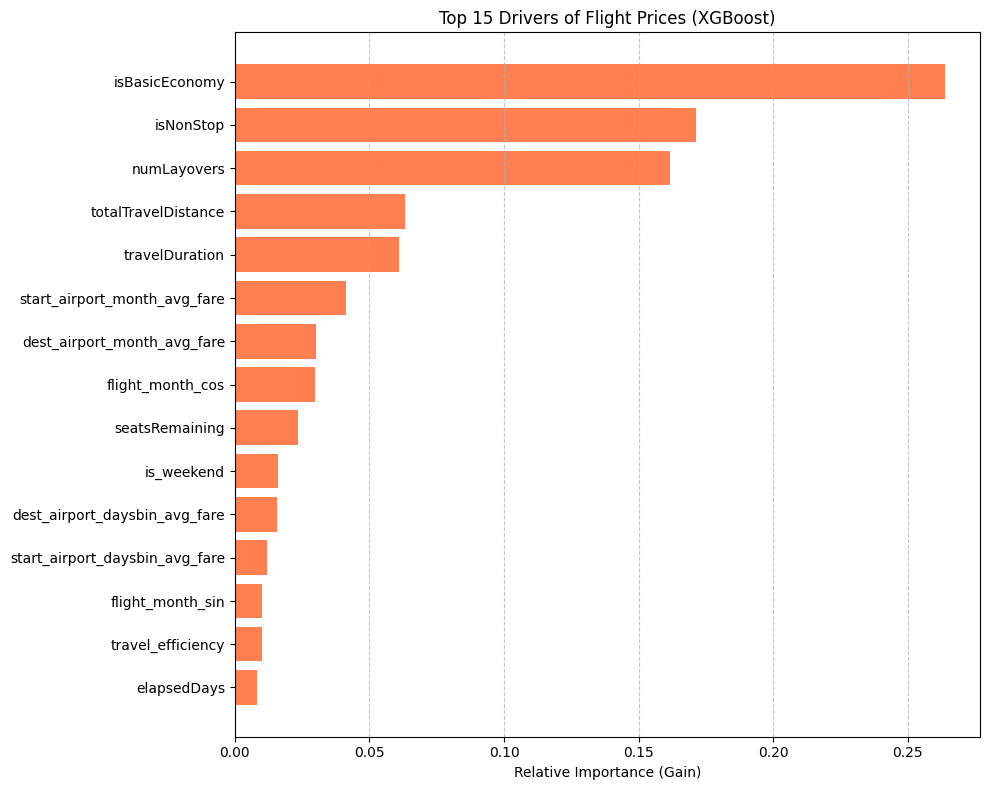

In [6]:
plt.figure(figsize=(10, 8))
top_15 = importance_df.tail(15)
plt.barh(top_15['Feature'], top_15['Importance'], color='coral')
plt.xlabel('Relative Importance (Gain)')
plt.title('Top 15 Drivers of Flight Prices (XGBoost)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("xgboost_feature_importance.png", dpi=300)  # Save the figure with high resolution
plt.show()

In [4]:
# Calculate standard R2
r2 = r2_score(y_test, y_pred_test_dollars)

# Get the number of observations (n) and features (p)
n = X_test.shape[0]
p = X_test.shape[1]

# Calculate Adjusted R2
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"Testing Adjusted R^2: {adjusted_r2:.4f}")

Testing Adjusted R^2: 0.7438
